In [24]:
#%pip install wordcloud
#%pip install stylecloud
#%pip install googletrans
#%pip install emoji
#%pip install textblob
#%pip install vaderSentiment

Defaulting to user installation because normal site-packages is not writeable
  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd # import biblioteki pozwalającej na wczytanie danych w formie ramki danych, na których można wykonywac proste operacje 
import re #biblioteka pozwalająca na wyszukiwania wyrażeń regularnych w tekście
import nltk
nltk.download('stopwords') #ściągnięcie słownika z wyrazami nie niosącymi znaczenia tzw.stopwords
nltk.download('wordnet')
from nltk.corpus import stopwords #import biblioteki, która posiada słownik z stopwordsami
import matplotlib.pyplot as plt #blioteka pozwalająca na wizualizacje danych
from matplotlib import cm #import palety kolorów biblioteki matplotlib
import seaborn as sns #blioteka pozwalająca na wizualizacje danych
from wordcloud import WordCloud #biblioteka pozwalającca na tworzenie chmury słów
from nltk.stem import PorterStemmer #biblioteka pozwalajaca na stemantyzację
from nltk.stem.wordnet import WordNetLemmatizer #biblioteka pozwalajaca na lemantyzację
import collections # biblioteka pozwalająca na zliczanie słów, bigramów, trigramów
from nltk import bigrams #biblioteka do tworzenia bigramów
import pickle #biblioteka do tworzenia i otwierania plików w formacie pickle
import stylecloud #biblioteka do tworzenia chmury słów
from googletrans import Translator #biblioteka do tłumaczenia napisanego tekstu na inny język lub detekcji języka
import re #przy wulgaryzmach
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Iga\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Iga\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
C:\Users\Iga\AppData\Roaming\Python\Python313\site-packages\stylecloud\stylecloud.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [39]:
data = pd.read_csv("data_clean.csv", index_col = 0)

In [40]:
#jezeli w wiersz jest postem to ma tylko title, nie ma body
((data["type"]=="posts") & (data["body"].notna())).any()
#jezeli wiersz jest komentarzem to ma tylko body, nie ma title
((data["type"]=="comment") & (data["title"].notna())).any()

#krocej zapisane ze nie ma takiego wiersza w ktorym i w kolumnie title i body jest cokolwiek
((data["title"].notna()) & (data["body"].notna())).any()

np.False_

In [41]:
data["tresc"] = data[["title","body"]].fillna("").agg(" ".join, axis=1).str.strip() #łączy nam tekst z obu kolumn w jedna kolumne "tresc"

# ANALIZA DLA MILEY CYRUS

In [42]:
data_miley = data[data["subreddit"] != "hannahmontana"]
data_miley["year"].value_counts()

year
2024    13783
2025    12694
2020     8672
2019     7347
2026     5691
2021     4557
2015     4312
2014     3886
2023     2701
2018     2640
2013     2507
2017     2407
2016     2382
2022     1782
2012      918
2011      229
2010      163
2009        5
2008        1
Name: count, dtype: int64

In [43]:
#OBCINAMY NA RÓŻNE PODOKRESY
data_miley_08_18 = data[(data["subreddit"] != "hannahmontana") & (data["year"].between(2008, 2018))]  # początki
data_miley_19_20 = data[(data["subreddit"] != "hannahmontana") & (data["year"].between(2019, 2020))]  # szczyt/pik i problemy rodzinne oraz zdrowotne
data_miley_21_23 = data[(data["subreddit"] != "hannahmontana") & (data["year"].between(2021, 2023))]  # rockowa diva i niezależność
data_miley_24_26 = data[(data["subreddit"] != "hannahmontana") & (data["year"].between(2024, 2026))]  # dojrzałość/porównanie z r/Hannah

In [7]:
data_miley_08_18_df = pd.DataFrame(data_miley_08_18, columns=['tresc'])
data_miley_19_20_df = pd.DataFrame(data_miley_19_20, columns=['tresc'])
data_miley_21_23_df = pd.DataFrame(data_miley_21_23, columns=['tresc'])
data_miley_24_26_df = pd.DataFrame(data_miley_24_26, columns=['tresc'])

In [15]:
dictionary = {
    "dont": "don't",
    "didnt": "didn't",
    "wasnt": "wasn't",
    "werent": "weren't",
    "shes": "she's",
    "ive": "I've",
    "cant": "can't",
    "hes": "he's",
    "isnt": "isn't",
    "arent": "aren't"
}

def normalize_text(text):
    new_words = text.split()
    new_words = [dictionary.get(w, w) for w in new_words]
    return " ".join(new_words)

In [9]:
wulgaryzmy_mapa = {
    'fucking': 'f*cking',
    'fuck': 'f*ck',
    'shitty': 'sh*tty',
    'shit': 'sh*t',
    'bitches': 'b*tches',
    'bitch': 'b*tch',
    'ass': 'a*s',
    'tits': 't*ts',
    'pussy': 'p*ssy',
    'cum': 'c*m',
    'cock': 'c*ck',
    'sex': 's*x'
}

def cenzuruj_wulgaryzmy(text):
    if not isinstance(text, str):
        return text
    
    for slowo, zamiennik in wulgaryzmy_mapa.items():
        wzorzec = r'\b' + slowo + r'\b'
        text = re.sub(wzorzec, zamiennik, text, flags=re.IGNORECASE)
    return text

In [13]:
#Usuwanie stopwords
def remove_my_stopwords(text):
    stop_words = stopwords.words("english") 
    stop_words.extend(["oah", "haha", "hey", "yeah", "oh", "lol", "omg", "ain't", "im", "that's", "i've", "I've", "miley", "mileys", "miley's", "cyrus", "would", "could", "doesnt", "doesn't", "can't", "also", "pic", "dm", "ig", "tho", "tbh", "imo", "id", "thats", "wow", "us", "got"])
    filtred_words=[]
    for word in text.split():
        if word not in stop_words:
            filtred_words.append(word)
    return filtred_words

In [14]:
data_miley_08_18_string = " ".join(data_miley_08_18_df['tresc'].fillna(""))
data_miley_19_20_string = " ".join(data_miley_19_20_df['tresc'].fillna(""))
data_miley_21_23_string = " ".join(data_miley_21_23_df['tresc'].fillna(""))
data_miley_24_26_string = " ".join(data_miley_24_26_df['tresc'].fillna(""))

In [15]:
#oczyszczenie
import emoji

# 2008-2018
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].fillna("")
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: str(x).lower())
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: re.sub('(http\S+)', "", x)) #linki
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: re.sub('#(\w+)', "", x)) #hashtagi
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: emoji.replace_emoji(x, "")) #emoji
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: re.sub('\d+', "", x)) #cyfry
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: re.sub(r"\s+", " ", x)) #spacje
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: re.sub("[^\w\s']+", "", x)) #znaki interpunkcyjne i ich ciagi np (???!!!) ale zachowuje apostrofy
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: str(x).strip()) #spacje okalajace wyraz otacza 
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(normalize_text)
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: remove_my_stopwords(x))
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: " ".join(x))

In [16]:
# 2019-2020
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].fillna("")
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: str(x).lower())
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: re.sub('(http\S+)', "", x)) #linki
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: re.sub('#(\w+)', "", x)) #hashtagi
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: emoji.replace_emoji(x, "")) #emoji
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: re.sub('\d+', "", x)) #cyfry
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: re.sub(r"\s+", " ", x)) #spacje
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: re.sub("[^\w\s']+", "", x)) #znaki interpunkcyjne i ich ciagi np (???!!!) ale zachowuje apostrofy
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: str(x).strip()) #spacje okalajace wyraz otacza 
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(normalize_text)
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: remove_my_stopwords(x))
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: " ".join(x))

In [17]:
# 2021-2023
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].fillna("")
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: str(x).lower())
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: re.sub('(http\S+)', "", x)) #linki
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: re.sub('#(\w+)', "", x)) #hashtagi
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: emoji.replace_emoji(x, "")) #emoji
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: re.sub('\d+', "", x)) #cyfry
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: re.sub(r"\s+", " ", x)) #spacje
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: re.sub("[^\w\s']+", "", x)) #znaki interpunkcyjne i ich ciagi np (???!!!) ale zachowuje apostrofy
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: str(x).strip()) #spacje okalajace wyraz otacza 
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(normalize_text)
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: remove_my_stopwords(x))
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: " ".join(x))

In [18]:
# 2024-2026
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].fillna("")
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: str(x).lower())
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub('(http\S+)', "", x)) #linki
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub('#(\w+)', "", x)) #hashtagi
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: emoji.replace_emoji(x, "")) #emoji
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub('\d+', "", x)) #cyfry
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub(r"\s+", " ", x)) #spacje
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub("[^\w\s']+", "", x)) #znaki interpunkcyjne i ich ciagi np (???!!!) ale zachowuje apostrofy
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: str(x).strip()) #spacje okalajace wyraz otacza 
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(normalize_text)
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: remove_my_stopwords(x))
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: " ".join(x))

In [21]:
data_miley_08_18_str = data_miley_08_18_df['tresc'].fillna("").str.lower().str.split().explode().dropna().tolist()
data_miley_19_20_str = data_miley_19_20_df['tresc'].fillna("").str.lower().str.split().explode().dropna().tolist()
data_miley_21_23_str = data_miley_21_23_df['tresc'].fillna("").str.lower().str.split().explode().dropna().tolist()
data_miley_24_26_str = data_miley_24_26_df['tresc'].fillna("").str.lower().str.split().explode().dropna().tolist()

In [22]:
#proces stemantyzacji - sprowadzanie słów do ich rdzeni
#Wywołaj konwerter pozwalający na stemming tekstu za pomocą funkcji PorterStemmer()
ps = PorterStemmer()

<Axes: xlabel='slowa'>

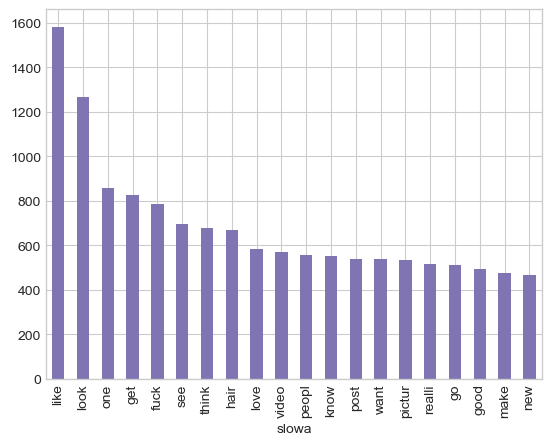

In [23]:
# 2008-2018
#Stwórz pustą listę o nazwie stemmed_words
stemmed_words_08_18 = []
#Wykonaj pętle po słowach, która będzie każde słowo w bloku tekstu sprowadzać do rdzenia i zapisz je do listy stemmed_words
for word in data_miley_08_18_str:
    stemmed_words_08_18.append(ps.stem(word))

lista_slow_stem_08_18 = pd.DataFrame(stemmed_words_08_18)
lista_slow_stem_08_18.rename(columns = {0:"slowa"}, inplace=True)
lista_slow_stem_08_18.slowa.value_counts().head(20).plot(kind = "bar", color = "#8074B2")

In [28]:
lista_slow_stem_08_18.slowa.value_counts().head(40)

slowa
like      1582
look      1264
one        855
get        826
fuck       786
see        696
think      678
hair       668
love       584
video      568
peopl      556
know       552
post       540
want       536
pictur     532
realli     515
go         513
good       495
make       475
new        467
ass        415
time       414
say        411
still      408
show       380
thing      367
photo      364
even       363
much       351
right      339
hot        336
shit       336
back       326
need       324
pic        306
nice       306
year       294
day        283
actual     278
sexi       276
Name: count, dtype: int64

<Axes: xlabel='slowa'>

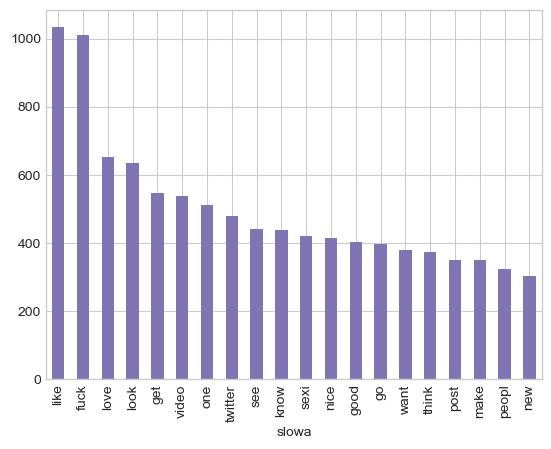

In [24]:
# 2019-2020
#Stwórz pustą listę o nazwie stemmed_words
stemmed_words_19_20 = []
#Wykonaj pętle po słowach, która będzie każde słowo w bloku tekstu sprowadzać do rdzenia i zapisz je do listy stemmed_words
for word in data_miley_19_20_str:
    stemmed_words_19_20.append(ps.stem(word))

lista_slow_stem_19_20 = pd.DataFrame(stemmed_words_19_20)
lista_slow_stem_19_20.rename(columns = {0:"slowa"}, inplace=True)
lista_slow_stem_19_20.slowa.value_counts().head(20).plot(kind = "bar", color = "#8074B2")

In [29]:
lista_slow_stem_19_20.slowa.value_counts().head(40)

slowa
like       1033
fuck       1010
love        654
look        634
get         547
video       539
one         512
twitter     479
see         442
know        438
sexi        422
nice        414
good        404
go          398
want        380
think       374
post        351
make        350
peopl       323
new         304
time        304
hot         301
say         298
realli      297
need        294
thank       290
shit        281
ye          281
heart       259
ass         258
even        254
music       251
ray         248
much        233
watch       230
beauti      222
back        220
right       214
song        213
come        209
Name: count, dtype: int64

<Axes: xlabel='slowa'>

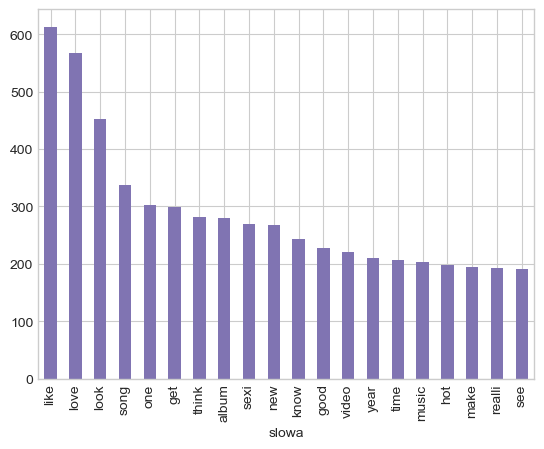

In [25]:
# 2021-2023
#Stwórz pustą listę o nazwie stemmed_words
stemmed_words_21_23 = []
#Wykonaj pętle po słowach, która będzie każde słowo w bloku tekstu sprowadzać do rdzenia i zapisz je do listy stemmed_words
for word in data_miley_21_23_str:
    stemmed_words_21_23.append(ps.stem(word))

lista_slow_stem_21_23 = pd.DataFrame(stemmed_words_21_23)
lista_slow_stem_21_23.rename(columns = {0:"slowa"}, inplace=True)
lista_slow_stem_21_23.slowa.value_counts().head(20).plot(kind = "bar", color = "#8074B2")

In [30]:
lista_slow_stem_21_23.slowa.value_counts().head(40)

slowa
like       613
love       568
look       453
song       337
one        303
get        299
think      281
album      280
sexi       270
new        268
know       244
good       228
video      220
year       210
time       207
music      203
hot        198
make       194
realli     193
see        191
heart      187
want       185
fuck       176
beauti     169
flower     167
cover      160
live       158
twitter    154
show       153
much       147
amaz       143
thank      140
need       138
go         137
post       136
best       136
plastic    135
ass        129
nice       123
peopl      123
Name: count, dtype: int64

<Axes: xlabel='slowa'>

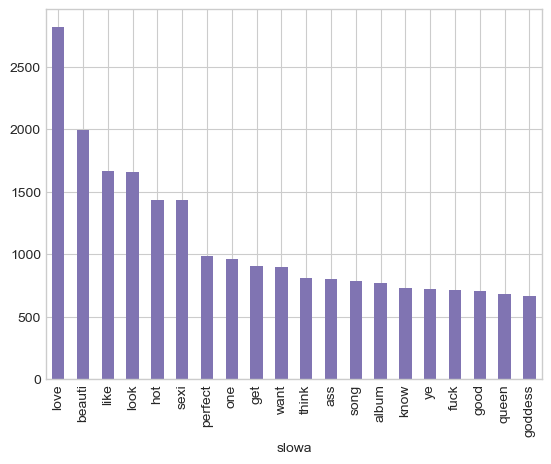

In [26]:
# 2024-2026
#Stwórz pustą listę o nazwie stemmed_words
stemmed_words_24_26 = []
#Wykonaj pętle po słowach, która będzie każde słowo w bloku tekstu sprowadzać do rdzenia i zapisz je do listy stemmed_words
for word in data_miley_24_26_str:
    stemmed_words_24_26.append(ps.stem(word))

lista_slow_stem_24_26 = pd.DataFrame(stemmed_words_24_26)
lista_slow_stem_24_26.rename(columns = {0:"slowa"}, inplace=True)
lista_slow_stem_24_26.slowa.value_counts().head(20).plot(kind = "bar", color = "#8074B2")

In [27]:
lista_slow_stem_24_26.slowa.value_counts().head(40)

slowa
love       2816
beauti     1990
like       1667
look       1657
hot        1435
sexi       1434
perfect     983
one         960
get         907
want        900
think       810
ass         803
song        781
album       767
know        727
ye          717
fuck        712
good        704
queen       683
goddess     665
time        655
see         624
make        618
bodi        605
alway       584
gorgeou     545
amaz        530
best        520
realli      502
much        499
someth      459
go          449
need        444
absolut     440
show        426
leg         424
face        419
damn        408
great       404
feel        397
Name: count, dtype: int64

In [32]:
#Lematyzacja - sprowadzenie słów do wersji podstawowej
wnl = WordNetLemmatizer()

<Axes: xlabel='slowa'>

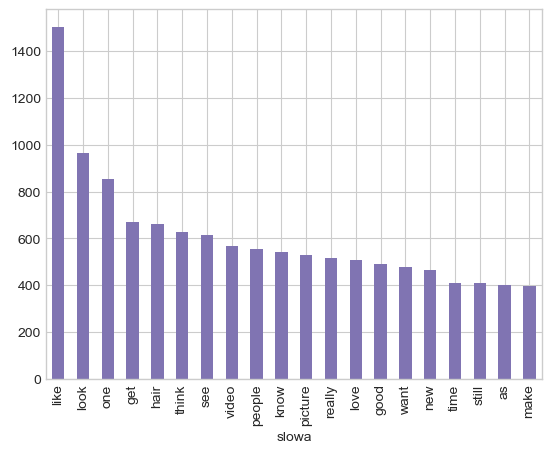

In [34]:
lemmed_words_08_18 = []

for word in data_miley_08_18_str:
    lemmed_words_08_18.append(wnl.lemmatize(word))
                        
lista_slow_lem_08_18 = pd.DataFrame(lemmed_words_08_18)
lista_slow_lem_08_18.rename(columns = {0:"slowa"}, inplace=True)
lista_slow_lem_08_18.slowa.value_counts().head(20).plot(kind = "bar", color = "#8074B2")

In [62]:
lista_slow_lem_08_18.slowa.value_counts().head(40)

slowa
like       1503
look        965
one         855
get         672
hair        663
think       628
see         613
video       568
people      556
know        543
picture     530
really      515
love        510
good        491
want        476
new         467
time        409
still       408
as          403
make        398
fucking     384
fuck        381
thing       367
photo       364
even        356
much        351
right       339
shit        335
hot         328
say         322
back        320
go          315
need        308
pic         306
nice        297
year        294
post        289
show        286
day         283
sexy        273
Name: count, dtype: int64

<Axes: xlabel='slowa'>

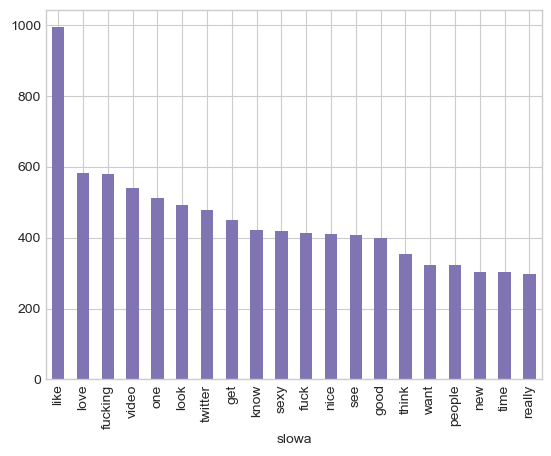

In [35]:
lemmed_words_19_20 = []

for word in data_miley_19_20_str:
    lemmed_words_19_20.append(wnl.lemmatize(word))
                        
lista_slow_lem_19_20 = pd.DataFrame(lemmed_words_19_20)
lista_slow_lem_19_20.rename(columns = {0:"slowa"}, inplace=True)
lista_slow_lem_19_20.slowa.value_counts().head(20).plot(kind = "bar", color = "#8074B2")

In [41]:
lista_slow_lem_19_20.slowa.value_counts().head(40)

slowa
like       993
love       582
fucking    580
video      539
one        512
look       492
twitter    479
get        449
know       423
sexy       419
fuck       412
nice       411
see        407
good       400
think      355
want       323
people     323
new        304
time       304
really     297
hot        295
make       291
go         282
shit       280
yes        280
need       277
heart      258
as         256
even       253
post       251
ray        248
music      240
much       233
back       217
right      213
song       213
say        211
album      205
still      203
day        197
Name: count, dtype: int64

<Axes: xlabel='slowa'>

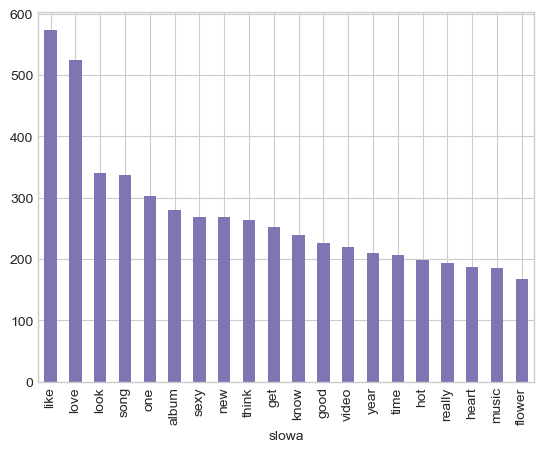

In [37]:
lemmed_words_21_23 = []

for word in data_miley_21_23_str:
    lemmed_words_21_23.append(wnl.lemmatize(word))
                        
lista_slow_lem_21_23 = pd.DataFrame(lemmed_words_21_23)
lista_slow_lem_21_23.rename(columns = {0:"slowa"}, inplace=True)
lista_slow_lem_21_23.slowa.value_counts().head(20).plot(kind = "bar", color = "#8074B2")

In [42]:
lista_slow_lem_21_23.slowa.value_counts().head(40)

slowa
like         574
love         525
look         340
song         337
one          303
album        280
sexy         269
new          268
think        264
get          253
know         239
good         227
video        220
year         210
time         207
hot          198
really       193
heart        187
music        186
flower       167
see          167
make         166
want         160
twitter      154
cover        148
much         147
beautiful    146
amazing      143
best         136
plastic      135
live         133
show         132
need         128
as           128
yes          126
people       123
nice         121
ever         119
body         118
still        116
Name: count, dtype: int64

<Axes: xlabel='slowa'>

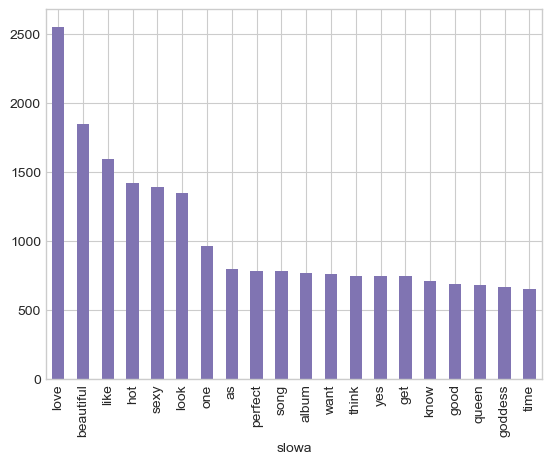

In [38]:
lemmed_words_24_26 = []

for word in data_miley_24_26_str:
    lemmed_words_24_26.append(wnl.lemmatize(word))
                        
lista_slow_lem_24_26 = pd.DataFrame(lemmed_words_24_26)
lista_slow_lem_24_26.rename(columns = {0:"slowa"}, inplace=True)
lista_slow_lem_24_26.slowa.value_counts().head(20).plot(kind = "bar", color = "#8074B2")

In [39]:
lista_slow_lem_24_26.slowa.value_counts().head(40)

slowa
love         2553
beautiful    1846
like         1596
hot          1420
sexy         1394
look         1349
one           960
as            795
perfect       783
song          781
album         767
want          763
think         747
yes           745
get           745
know          709
good          688
queen         683
goddess       665
time          652
body          603
always        582
make          547
gorgeous      545
amazing       526
see           526
best          520
really        502
much          499
woman         463
something     456
fuck          432
leg           422
face          413
need          409
damn          404
great         399
every         384
new           378
way           377
Name: count, dtype: int64

## LISTA TOP SŁÓW - NA RAZIE TEGO NIE ZMIENIŁAM

In [17]:
df = pd.DataFrame(data_miley_08_18_df, columns = ['tresc'])
df.head()

,tresc
7877,weirder three eyed billygoat flatbed truck mid...
7878,think movie ended travis
7879,said say jake cheater photo even imply anythin...
7880,season superior enough said
7881,gonna new lizzie mcguire show got scrapped dou...


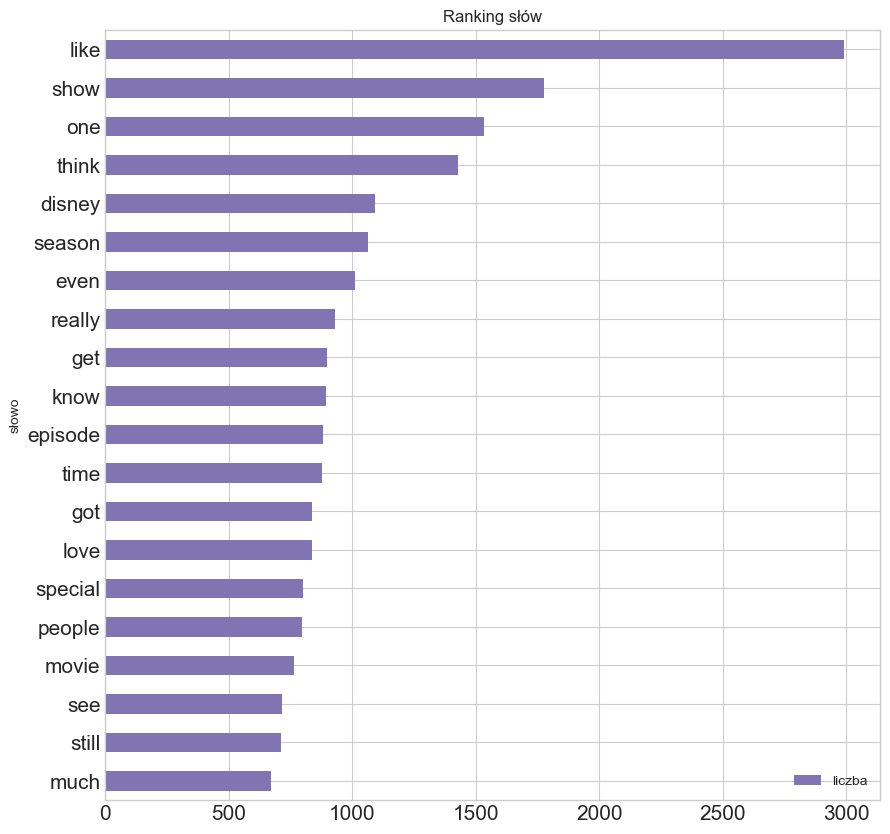

In [18]:
#statystykA częstości występowania słów w postach/komentarzach ze slowek hannahmontana
words = pd.DataFrame(data_hannah_str).value_counts().head(20).rename_axis("słowo").reset_index(name="liczba")
#Zwizualizuj otrzymane wyniki
words.sort_values(by='liczba').plot.barh(x='słowo',y='liczba', figsize=(10,10), fontsize=15, title='Ranking słów', color="#8074B2");

## CHMURA SŁÓW

In [45]:
# LEMATYZACJA LIST STR
wnl = WordNetLemmatizer()

data_miley_08_18_str_lem = [wnl.lemmatize(word) for word in data_miley_08_18_str]
data_miley_19_20_str_lem = [wnl.lemmatize(word) for word in data_miley_19_20_str]
data_miley_21_23_str_lem = [wnl.lemmatize(word) for word in data_miley_21_23_str]
data_miley_24_26_str_lem = [wnl.lemmatize(word) for word in data_miley_24_26_str]

In [49]:
# 2008-2018
word_cloud_words_08_18 = pd.DataFrame(data_miley_08_18_str_lem).value_counts().head(80).rename_axis("word").reset_index(name="count")
wystapienia_08_18 = dict(zip(word_cloud_words_08_18["word"], word_cloud_words_08_18["count"]))

In [50]:
# 2019-2020
word_cloud_words_19_20 = pd.DataFrame(data_miley_19_20_str_lem).value_counts().head(80).rename_axis("word").reset_index(name="count")
wystapienia_19_20 = dict(zip(word_cloud_words_19_20["word"], word_cloud_words_19_20["count"]))

In [51]:
# 2021-2023
word_cloud_words_21_23 = pd.DataFrame(data_miley_21_23_str_lem).value_counts().head(80).rename_axis("word").reset_index(name="count")
wystapienia_21_23 = dict(zip(word_cloud_words_21_23["word"], word_cloud_words_21_23["count"]))

In [52]:
# 2024-2026
word_cloud_words_24_26 = pd.DataFrame(data_miley_24_26_str_lem).value_counts().head(80).rename_axis("word").reset_index(name="count")
wystapienia_24_26 = dict(zip(word_cloud_words_24_26["word"], word_cloud_words_24_26["count"]))

In [56]:
colors = ["#dabcff","#deacde","#9e4a9e","#ffc370","#ffc6d0","#800080","#b266b2","#a64ca6","#b266b2"]
color_function = lambda *args, **kwargs: np.random.choice(colors)

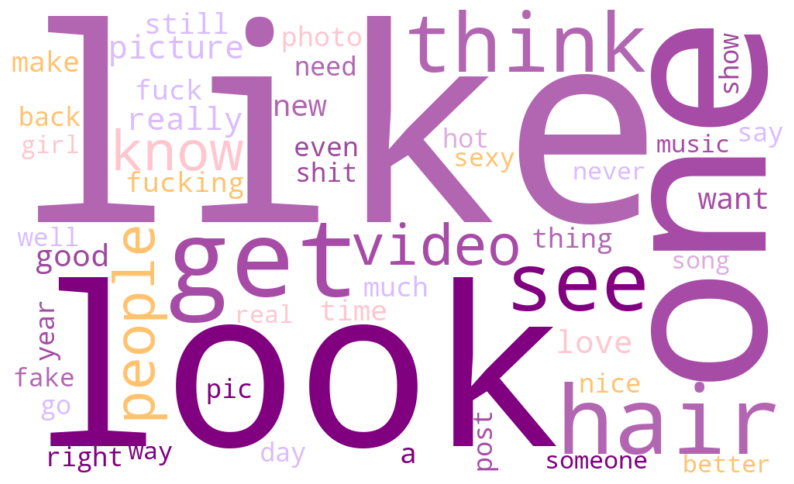

In [72]:
#Utwórz chmurę słów
#Wywołanie obiektu odpowiedzialnego za tworzenie chmury słów WordCloud()
# 2008 - 2018
plt.figure(figsize=(10,10))
wc_08_18 = WordCloud(background_color = 'white', color_func = color_function, max_words = 50, width=1000, height=600, colormap = cm.plasma).generate_from_frequencies(wystapienia_08_18)
#Utwórz chmurę słow za pomocą funkcj wc.generate(), a następnie ją wyświetl za pomocą funkcji plt.imshow()
plt.imshow(wc_08_18, interpolation = 'bilinear')
plt.axis('off');

svg_string = wc_08_18.to_svg(embed_font=True)

with open("chmura_miley_08_18.svg", "w", encoding="utf-8") as f:
    f.write(svg_string)

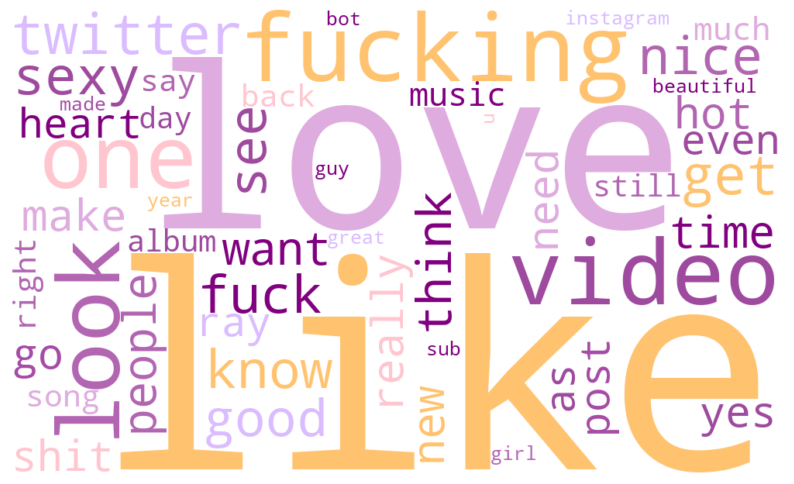

In [73]:
#Utwórz chmurę słów
#Wywołanie obiektu odpowiedzialnego za tworzenie chmury słów WordCloud()
# 2019 - 2020
plt.figure(figsize=(10,10))
wc_19_20 = WordCloud(background_color = 'white', color_func = color_function, max_words = 50, width=1000, height=600, colormap = cm.plasma).generate_from_frequencies(wystapienia_19_20)
#Utwórz chmurę słow za pomocą funkcj wc.generate(), a następnie ją wyświetl za pomocą funkcji plt.imshow()
plt.imshow(wc_19_20, interpolation = 'bilinear')
plt.axis('off');

svg_string = wc_19_20.to_svg(embed_font=True)

with open("chmura_miley_19_20.svg", "w", encoding="utf-8") as f:
    f.write(svg_string)

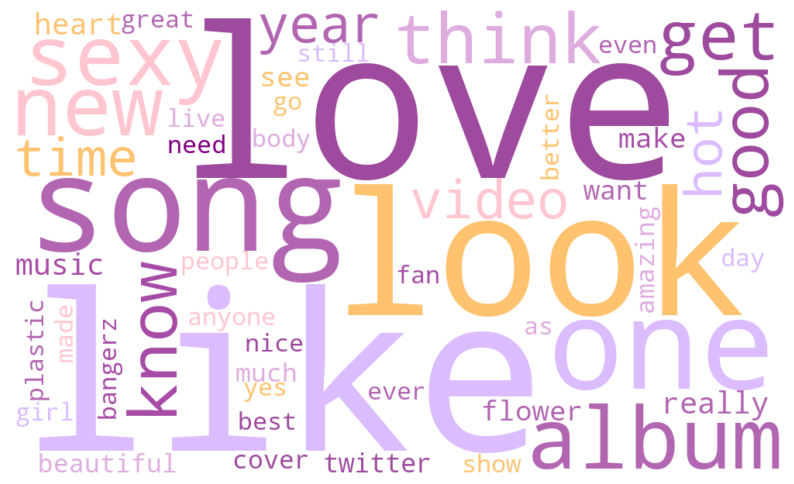

In [74]:
#Utwórz chmurę słów
#Wywołanie obiektu odpowiedzialnego za tworzenie chmury słów WordCloud()
# 2021 - 2023
plt.figure(figsize=(10,10))
wc_21_23 = WordCloud(background_color = 'white', color_func = color_function, max_words = 50, width=1000, height=600, colormap = cm.plasma).generate_from_frequencies(wystapienia_21_23)
#Utwórz chmurę słow za pomocą funkcj wc.generate(), a następnie ją wyświetl za pomocą funkcji plt.imshow()
plt.imshow(wc_21_23, interpolation = 'bilinear')
plt.axis('off');

svg_string = wc_21_23.to_svg(embed_font=True)

with open("chmura_miley_21_23.svg", "w", encoding="utf-8") as f:
    f.write(svg_string)

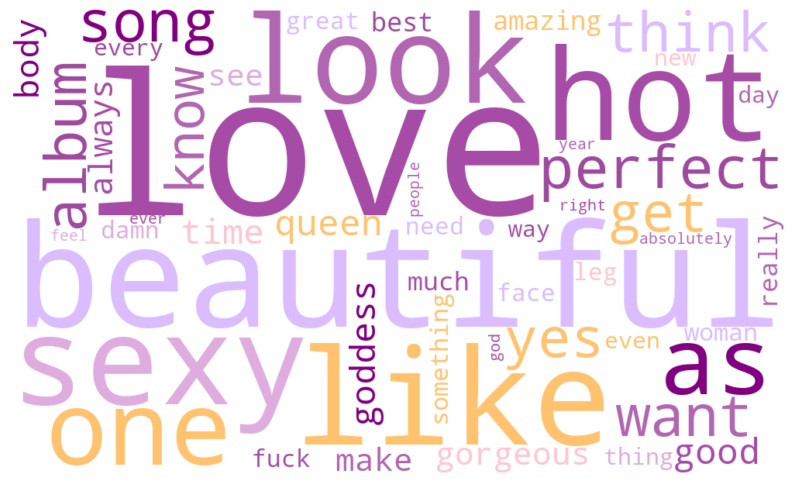

In [75]:
#Utwórz chmurę słów
#Wywołanie obiektu odpowiedzialnego za tworzenie chmury słów WordCloud()
# 2024 - 2026
plt.figure(figsize=(10,10))
wc_24_26 = WordCloud(background_color = 'white', color_func = color_function, max_words = 50, width=1000, height=600, colormap = cm.plasma).generate_from_frequencies(wystapienia_24_26)
#Utwórz chmurę słow za pomocą funkcj wc.generate(), a następnie ją wyświetl za pomocą funkcji plt.imshow()
plt.imshow(wc_24_26, interpolation = 'bilinear')
plt.axis('off');

svg_string = wc_24_26.to_svg(embed_font=True)

with open("chmura_miley_24_26.svg", "w", encoding="utf-8") as f:
    f.write(svg_string)

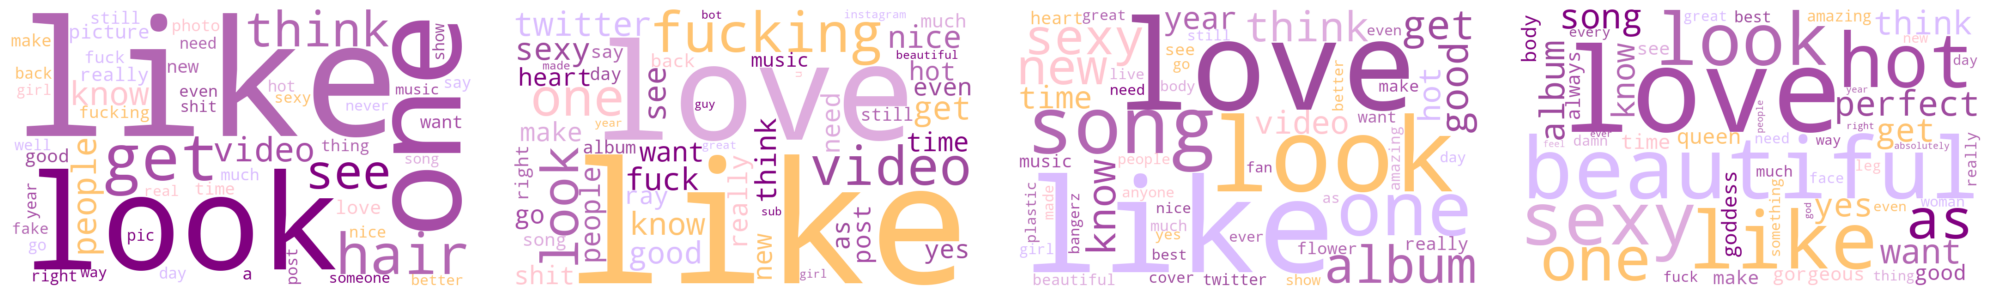

In [76]:
fig, axes = plt.subplots(nrows = 1, ncols = 4, figsize = (20, 10))

axes[0].imshow(wc_08_18, interpolation='bilinear')
axes[0].axis('off')

axes[1].imshow(wc_19_20, interpolation='bilinear')
axes[1].axis('off')

axes[2].imshow(wc_21_23, interpolation='bilinear')
axes[2].axis('off')

axes[3].imshow(wc_24_26, interpolation='bilinear')
axes[3].axis('off')

plt.tight_layout(w_pad = 3.0)

plt.savefig("kolaż_chmur_miley.svg", format = "svg", bbox_inches = 'tight', pad_inches = 0.1)

## ANALIZA WYDŹWIĘKU - NA RAZIE TEGO NIE ZMIENIŁAM

In [9]:
from textblob import TextBlob
from nltk.corpus import stopwords, twitter_samples
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import seaborn as sns
import numpy as np
import re
import matplotlib.pyplot as plt
import pandas as pd
import nltk

In [10]:
from nltk.corpus import stopwords

stop = set(stopwords.words("english"))

safe_stopwords = stop - {
    "not", "no", "nor",
    "don't", "didn't", "wasn't", "won't", "can't",
    "isn't", "aren't", "couldn't", "wouldn't"
}

In [11]:
#Usuwanie stopwords
def remove_my_stopwords(text):
    stop_words = safe_stopwords
    stop_words.update({"oah", "haha", "hey", "yeah", "oh", "lol", "omg", "im"})
    filtred_words=[]
    for word in text.split():
        if word not in stop_words:
            filtred_words.append(word)
    return filtred_words

In [12]:
data_miley_08_18_df = pd.DataFrame(data_miley_08_18, columns=['tresc'])
data_miley_19_20_df = pd.DataFrame(data_miley_19_20, columns=['tresc'])
data_miley_21_23_df = pd.DataFrame(data_miley_21_23, columns=['tresc'])
data_miley_24_26_df = pd.DataFrame(data_miley_24_26, columns=['tresc'])

In [16]:
#oczyszczenie
import emoji

# 2008-2018
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].fillna("")
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: str(x).lower())
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: re.sub('(http\S+)', "", x)) #linki
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: re.sub('#(\w+)', "", x)) #hashtagi
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: emoji.replace_emoji(x, "")) #emoji
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: re.sub('\d+', "", x)) #cyfry
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: re.sub(r"\s+", " ", x)) #spacje
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: re.sub("[^\w\s']+", "", x)) #znaki interpunkcyjne i ich ciagi np (???!!!) ale zachowuje apostrofy
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: str(x).strip()) #spacje okalajace wyraz otacza 
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(normalize_text)
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: remove_my_stopwords(x))
data_miley_08_18_df['tresc'] = data_miley_08_18_df['tresc'].apply(lambda x: " ".join(x))

In [17]:
# 2019-2020
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].fillna("")
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: str(x).lower())
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: re.sub('(http\S+)', "", x)) #linki
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: re.sub('#(\w+)', "", x)) #hashtagi
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: emoji.replace_emoji(x, "")) #emoji
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: re.sub('\d+', "", x)) #cyfry
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: re.sub(r"\s+", " ", x)) #spacje
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: re.sub("[^\w\s']+", "", x)) #znaki interpunkcyjne i ich ciagi np (???!!!) ale zachowuje apostrofy
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: str(x).strip()) #spacje okalajace wyraz otacza 
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(normalize_text)
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: remove_my_stopwords(x))
data_miley_19_20_df['tresc'] = data_miley_19_20_df['tresc'].apply(lambda x: " ".join(x))

In [18]:
# 2021-2023
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].fillna("")
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: str(x).lower())
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: re.sub('(http\S+)', "", x)) #linki
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: re.sub('#(\w+)', "", x)) #hashtagi
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: emoji.replace_emoji(x, "")) #emoji
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: re.sub('\d+', "", x)) #cyfry
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: re.sub(r"\s+", " ", x)) #spacje
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: re.sub("[^\w\s']+", "", x)) #znaki interpunkcyjne i ich ciagi np (???!!!) ale zachowuje apostrofy
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: str(x).strip()) #spacje okalajace wyraz otacza 
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(normalize_text)
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: remove_my_stopwords(x))
data_miley_21_23_df['tresc'] = data_miley_21_23_df['tresc'].apply(lambda x: " ".join(x))

In [19]:
# 2024-2026
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].fillna("")
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: str(x).lower())
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub('(http\S+)', "", x)) #linki
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub('#(\w+)', "", x)) #hashtagi
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: emoji.replace_emoji(x, "")) #emoji
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub('\d+', "", x)) #cyfry
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub(r"\s+", " ", x)) #spacje
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub("[^\w\s']+", "", x)) #znaki interpunkcyjne i ich ciagi np (???!!!) ale zachowuje apostrofy
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: str(x).strip()) #spacje okalajace wyraz otacza 
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(normalize_text)
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: remove_my_stopwords(x))
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: " ".join(x))

In [21]:
miley_08_18_sentiment = data_miley_08_18_df['tresc'].fillna("").str.lower().str.split().explode().dropna()
miley_19_20_sentiment = data_miley_19_20_df['tresc'].fillna("").str.lower().str.split().explode().dropna()
miley_21_23_sentiment = data_miley_21_23_df['tresc'].fillna("").str.lower().str.split().explode().dropna()
miley_24_26_sentiment = data_miley_24_26_df['tresc'].fillna("").str.lower().str.split().explode().dropna()

In [22]:
miley_08_18_tekst = " ".join(miley_08_18_sentiment)
miley_19_20_tekst = " ".join(miley_19_20_sentiment)
miley_21_23_tekst = " ".join(miley_21_23_sentiment)
miley_24_26_tekst = " ".join(miley_24_26_sentiment)

In [35]:
#Częstość występowania pozytywnych słów w korpusie
# 2008-2018
miley_08_18_wystapienia = [] #utworzenie pustej listy

with open('pozytywne_slowa.txt') as file: #otworzenie pliku tekstowego z pozytywnymi słowami
    miley_08_18_pozytywne_slowa = file.read().split('\n') #zapisanie pozytywnych słów do zmiennej

    for slowo in miley_08_18_pozytywne_slowa: #pętl po słowach pozytywnych
        miley_08_18_wystapienia.append(tekst.count(slowo.strip())) #zliczenie słów pozytywnych w tekście za pomocą funkcji count
        
miley_08_18_pozytywne_slowa_wystapienia = pd.DataFrame(miley_08_18_wystapienia, 
                                                       index = miley_08_18_pozytywne_slowa, 
                                                       columns = ['liczba']) #zapisanie występujących pozytywnych słów do ramki danych

In [36]:
#Wyfiltruj pozytywne słowa z tekstu (gdy słowo występuje chociaż raz)
pozytywne_conjamniej_raz = pozytywne_slowa_wystapienia[pozytywne_slowa_wystapienia.liczba >1]
pozytywne_conjamniej_raz.sort_values(by = "liczba", ascending = False)

,liczba
,1295480
like,3356
love,1317
good,613
best,515
...,...
improved,2
striking,2
darling,2
steady,2


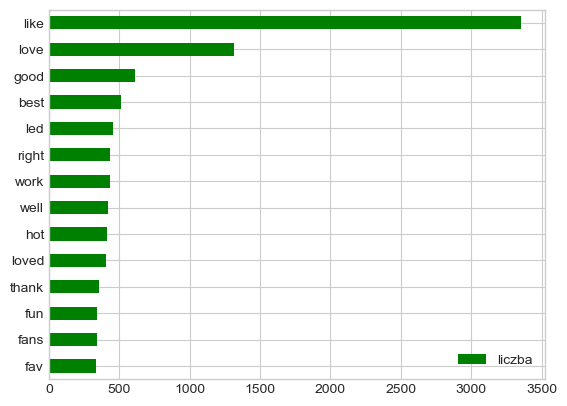

In [37]:
#Zwizualizuj wykrytych 14 pozytywnych słów
pozytywne_conjamniej_raz.sort_values(by = "liczba", ascending = False)[1:15].plot(kind = 'barh', color = 'green')
plt.gca().invert_yaxis()

In [38]:
#Częstość występowania pozytywnych słów w korpusie
wystapienia = [] #utworzenie pustej listy

with open('negatywne_slowa.txt', encoding = "latin1") as file: #otworzenie pliku tekstoweo z pozytywnymi słowami
    
    negatywne_slowa = file.read().split('\n') #zapisanie pozytywnych słów do zmiennej

    for slowo in negatywne_slowa: #pętl po słowach pozytywnych
        wystapienia.append(tekst.count(slowo.strip())) #zliczenie słów pozytywnych w tekście za pomocą funkcji count
        
negatywne_slowa_wystapienia = pd.DataFrame(wystapienia, index=negatywne_slowa, columns=['liczba']) #zapisanie występujących pozytywnych słów do ramki danych

In [39]:
negatywne_conjamniej_raz = negatywne_slowa_wystapienia[negatywne_slowa_wystapienia.liczba >1]
negatywne_conjamniej_raz.sort_values(by = "liczba", ascending = False)

,liczba
,1295480
ugh,1455
sin,1201
mad,665
din,645
...,...
madness,2
exaggeration,2
bugs,2
indulge,2


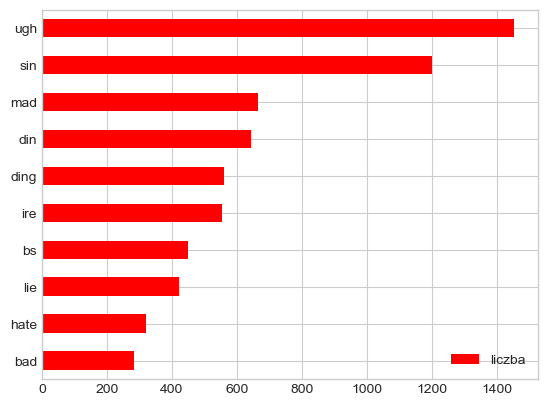

In [40]:
negatywne_conjamniej_raz.sort_values(by = "liczba", ascending = False)[1:11].plot(kind = 'barh', color = 'red')
plt.gca().invert_yaxis()

In [41]:
#VADER

In [44]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
#Wywołaj i przypisz do zmiennej model za pomocą funkcji SentimentIntensityAnalyzer()
sia = SentimentIntensityAnalyzer()
#Sprawdź przypisany sentyment do słow zwartych w słowniku Vadera za pomocą funkcji oboiekt.lexicon
sia.lexicon

{'$:': -1.5,
 '%)': -0.4,
 '%-)': -1.5,
 '&-:': -0.4,
 '&:': -0.7,
 "( '}{' )": 1.6,
 '(%': -0.9,
 "('-:": 2.2,
 "(':": 2.3,
 '((-:': 2.1,
 '(*': 1.1,
 '(-%': -0.7,
 '(-*': 1.3,
 '(-:': 1.6,
 '(-:0': 2.8,
 '(-:<': -0.4,
 '(-:o': 1.5,
 '(-:O': 1.5,
 '(-:{': -0.1,
 '(-:|>*': 1.9,
 '(-;': 1.3,
 '(-;|': 2.1,
 '(8': 2.6,
 '(:': 2.2,
 '(:0': 2.4,
 '(:<': -0.2,
 '(:o': 2.5,
 '(:O': 2.5,
 '(;': 1.1,
 '(;<': 0.3,
 '(=': 2.2,
 '(?:': 2.1,
 '(^:': 1.5,
 '(^;': 1.5,
 '(^;0': 2.0,
 '(^;o': 1.9,
 '(o:': 1.6,
 ")':": -2.0,
 ")-':": -2.1,
 ')-:': -2.1,
 ')-:<': -2.2,
 ')-:{': -2.1,
 '):': -1.8,
 '):<': -1.9,
 '):{': -2.3,
 ');<': -2.6,
 '*)': 0.6,
 '*-)': 0.3,
 '*-:': 2.1,
 '*-;': 2.4,
 '*:': 1.9,
 '*<|:-)': 1.6,
 '*\\0/*': 2.3,
 '*^:': 1.6,
 ',-:': 1.2,
 "---'-;-{@": 2.3,
 '--<--<@': 2.2,
 '.-:': -1.2,
 '..###-:': -1.7,
 '..###:': -1.9,
 '/-:': -1.3,
 '/:': -1.3,
 '/:<': -1.4,
 '/=': -0.9,
 '/^:': -1.0,
 '/o:': -1.4,
 '0-8': 0.1,
 '0-|': -1.2,
 '0:)': 1.9,
 '0:-)': 1.4,
 '0:-3': 1.5,
 '0:03': 1.9,
 '

In [45]:
# 2008-2018
data_miley_08_18["tresc"] = data_miley_08_18['tresc'].apply(normalize_text)
data_miley_08_18["tresc"] = data_miley_08_18['tresc'].apply(lambda x: re.sub(r"http\S+|www\S+", "", x)) #linki, strony internetowe
data_miley_08_18["tresc"] = data_miley_08_18['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
data_miley_08_18["vader"] = data_miley_08_18['tresc'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
data_miley_08_18.head()

C:\Users\Iga\AppData\Local\Temp\ipykernel_3104\3796399477.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_miley_08_18["tresc"] = data_miley_08_18['tresc'].apply(normalize_text)
C:\Users\Iga\AppData\Local\Temp\ipykernel_3104\3796399477.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_miley_08_18["tresc"] = data_miley_08_18['tresc'].apply(lambda x: re.sub(r"http\S+|www\S+", "", x)) #linki, strony internetowe
C:\Users\Iga\AppData\Local\Temp\ipykernel_3104\3796399477.py:4: SettingWithCopyWarnin

,type,subreddit,date,year,id,parent_id,author,title,body,score,over_18,tresc,vader
0,comments,cyrus,2017-06-13,2017,dittstm,6gvhln,cysenberg,NaN,I can't believe this sub is devoted to that ho...,1,NaN,I can't believe this sub is devoted to that ho...,-0.1027
1,comments,cyrus,2017-06-13,2017,ditveid,dittstm,cy_guy,NaN,?? what did ido???,1,NaN,?? what did ido???,0.0000
2,comments,cyrus,2017-06-13,2017,dityjgt,ditveid,cysenberg,NaN,The sub not your post lol. On the sidebar it s...,1,NaN,The sub not your post lol. On the sidebar it s...,-0.3252
3,comments,cyrus,2017-06-13,2017,dityugh,dityjgt,cy_guy,NaN,oh thats fuckin stupid,2,NaN,oh thats fuckin stupid,-0.5709
4893,posts,cyrus,2013-11-28,2013,1rn81s,NaN,TeleSpectacular,Miley Cyrus - Wrecking Ball live American Musi...,NaN,1,0.0,Miley Cyrus - Wrecking Ball live American Musi...,0.4588


In [46]:
# 2019-2020
data_miley_19_20["tresc"] = data_miley_19_20['tresc'].apply(normalize_text)
data_miley_19_20["tresc"] = data_miley_19_20['tresc'].apply(lambda x: re.sub(r"http\S+|www\S+", "", x)) #linki, strony internetowe
data_miley_19_20["tresc"] = data_miley_19_20['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
data_miley_19_20["vader"] = data_miley_19_20['tresc'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
data_miley_19_20.head()

C:\Users\Iga\AppData\Local\Temp\ipykernel_3104\1329333059.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_miley_19_20["tresc"] = data_miley_19_20['tresc'].apply(normalize_text)
C:\Users\Iga\AppData\Local\Temp\ipykernel_3104\1329333059.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_miley_19_20["tresc"] = data_miley_19_20['tresc'].apply(lambda x: re.sub(r"http\S+|www\S+", "", x)) #linki, strony internetowe
C:\Users\Iga\AppData\Local\Temp\ipykernel_3104\1329333059.py:4: SettingWithCopyWarnin

,type,subreddit,date,year,id,parent_id,author,title,body,score,over_18,tresc,vader
4,comments,cyrus,2019-10-29,2019,f5o6jgd,doilrx,TBD-101,NaN,Cyrus is the best,10,NaN,Cyrus is the best,0.6369
5,comments,cyrus,2019-10-29,2019,f5o7pj1,doip2c,Ohyahhhhhhhhhh,NaN,Which one is Italy?,8,NaN,Which one is Italy?,0.0000
6,comments,cyrus,2019-10-29,2019,f5o7prz,doilrx,D4NKD1X,NaN,yo papa cy i love you be my dad please,1,NaN,yo papa cy i love you be my dad please,0.7579
7,comments,cyrus,2019-10-29,2019,f5o7q3q,doilrx,spec_ops_bruh,NaN,Albania is great 🇦🇱,0,NaN,Albania is great 🇦🇱,0.6249
8,comments,cyrus,2019-10-29,2019,f5o7qc4,doiobe,dermernashin,NaN,JOE MAMA,6,NaN,JOE MAMA,0.0000


In [47]:
# 2021-2023
data_miley_21_23["tresc"] = data_miley_21_23['tresc'].apply(normalize_text)
data_miley_21_23["tresc"] = data_miley_21_23['tresc'].apply(lambda x: re.sub(r"http\S+|www\S+", "", x)) #linki, strony internetowe
data_miley_21_23["tresc"] = data_miley_21_23['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
data_miley_21_23["vader"] = data_miley_21_23['tresc'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
data_miley_21_23.head()

C:\Users\Iga\AppData\Local\Temp\ipykernel_3104\1041160809.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_miley_21_23["tresc"] = data_miley_21_23['tresc'].apply(normalize_text)
C:\Users\Iga\AppData\Local\Temp\ipykernel_3104\1041160809.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_miley_21_23["tresc"] = data_miley_21_23['tresc'].apply(lambda x: re.sub(r"http\S+|www\S+", "", x)) #linki, strony internetowe
C:\Users\Iga\AppData\Local\Temp\ipykernel_3104\1041160809.py:4: SettingWithCopyWarnin

,type,subreddit,date,year,id,parent_id,author,title,body,score,over_18,tresc,vader
4282,comments,cyrus,2021-01-02,2021,ghsvjl9,kogkx2,RoyaleHighUser,NaN,last time it was his mom now it's his fucking ...,4,NaN,last time it was his mom now it's his fucking ...,0.0000
4283,comments,cyrus,2021-01-04,2021,gi1mswy,g9rcgyo,DownvoteplsUwU,NaN,Because yes,1,NaN,Because yes,0.4019
4284,comments,cyrus,2021-01-05,2021,gi4ua4d,kqextj,V16V_Beast,NaN,Idk why are you asking,1,NaN,Idk why are you asking,-0.1027
4285,comments,cyrus,2021-01-06,2021,gia94v5,gi4ua4d,Intereze,NaN,bc i like it,0,NaN,bc i like it,0.3612
4286,comments,cyrus,2021-01-06,2021,gicbkux,krub8t,Intereze,NaN,9-828383838283,0,NaN,9-828383838283,0.0000


In [48]:
# 2024-2026
data_miley_24_26["tresc"] = data_miley_24_26['tresc'].apply(normalize_text)
data_miley_24_26["tresc"] = data_miley_24_26['tresc'].apply(lambda x: re.sub(r"http\S+|www\S+", "", x)) #linki, strony internetowe
data_miley_24_26["tresc"] = data_miley_24_26['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
data_miley_24_26["vader"] = data_miley_24_26['tresc'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
data_miley_24_26.head()

C:\Users\Iga\AppData\Local\Temp\ipykernel_3104\3519294297.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_miley_24_26["tresc"] = data_miley_24_26['tresc'].apply(normalize_text)
C:\Users\Iga\AppData\Local\Temp\ipykernel_3104\3519294297.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_miley_24_26["tresc"] = data_miley_24_26['tresc'].apply(lambda x: re.sub(r"http\S+|www\S+", "", x)) #linki, strony internetowe
C:\Users\Iga\AppData\Local\Temp\ipykernel_3104\3519294297.py:4: SettingWithCopyWarnin

,type,subreddit,date,year,id,parent_id,author,title,body,score,over_18,tresc,vader
58143,comments,mileycyrus,2024-01-01,2024,kfrs0x4,18u0oga,Mindless-General-538,NaN,so talented and such a perfect body,1,NaN,so talented and such a perfect body,0.807
58144,comments,mileycyrus,2024-01-01,2024,kfsn8v3,100c93c,KCFL1,NaN,What happened to her NYE show this year??,1,NaN,What happened to her NYE show this year??,0.000
58146,comments,mileycyrus,2024-01-02,2024,kfyf76l,kcwkmsb,mileycyrus4,NaN,Hello,1,NaN,Hello,0.000
58147,comments,mileycyrus,2024-01-02,2024,kfyf8d5,kd0llhm,mileycyrus4,NaN,Hello,1,NaN,Hello,0.000
58148,comments,mileycyrus,2024-01-02,2024,kfyf98g,kfhnge8,mileycyrus4,NaN,Hello,1,NaN,Hello,0.000


<Axes: >

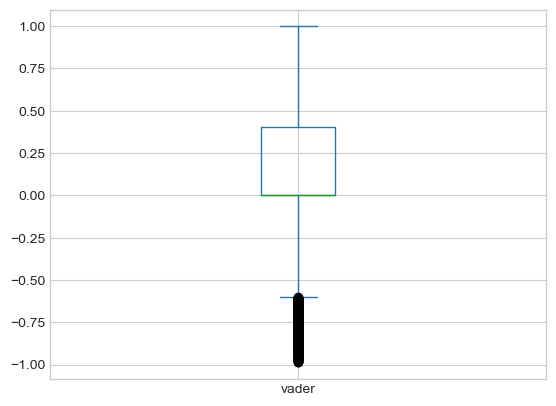

In [52]:
data_miley_08_18['vader'].plot.box()

<Axes: >

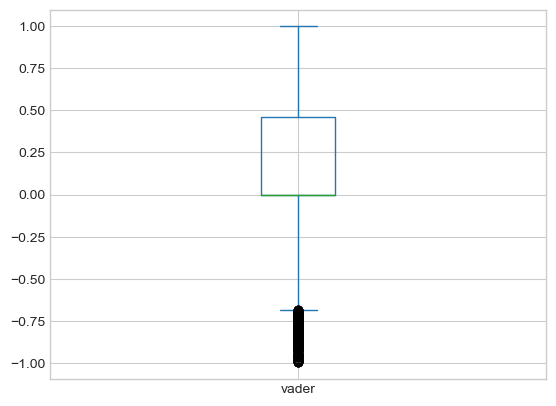

In [53]:
data_miley_19_20['vader'].plot.box()

<Axes: >

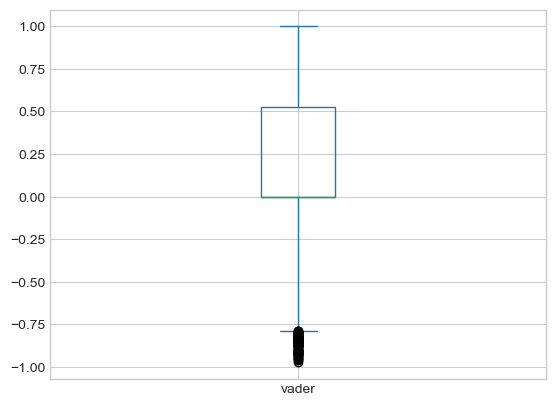

In [54]:
data_miley_21_23['vader'].plot.box()

<Axes: >

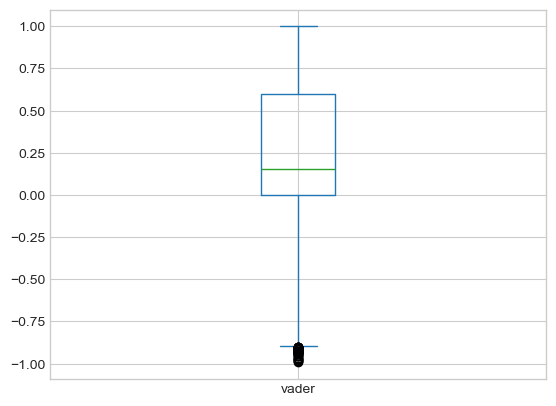

In [55]:
data_miley_24_26['vader'].plot.box()

<Axes: ylabel='vader'>

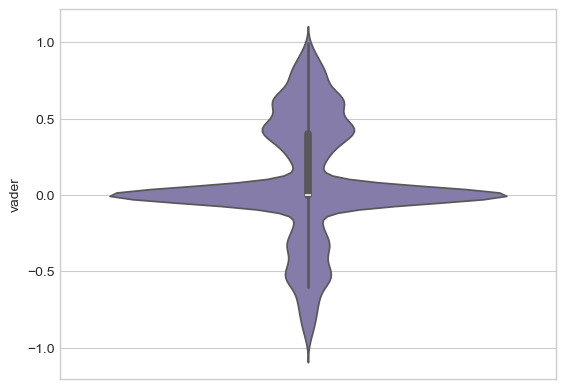

In [56]:
sns.violinplot(y = data_miley_08_18['vader'], color = "#8074B2")

<Axes: ylabel='vader'>

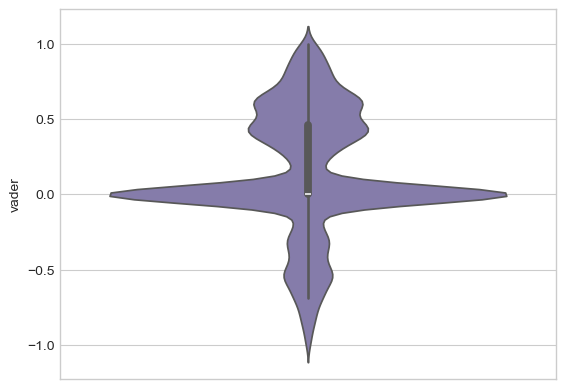

In [57]:
sns.violinplot(y = data_miley_19_20['vader'], color = "#8074B2")

<Axes: ylabel='vader'>

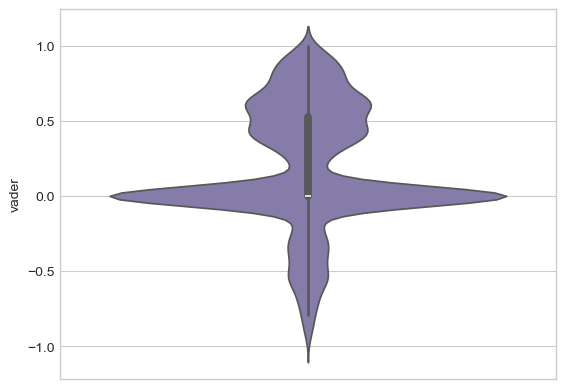

In [58]:
sns.violinplot(y = data_miley_21_23['vader'], color = "#8074B2")

<Axes: ylabel='vader'>

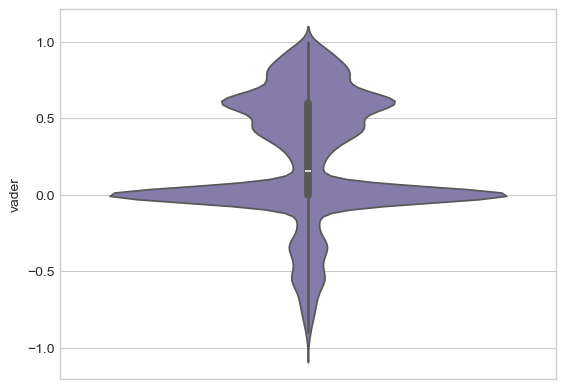

In [59]:
sns.violinplot(y = data_miley_24_26['vader'], color = "#8074B2")

In [60]:
data_miley_08_18.loc[:, "label"] = data_miley_08_18["vader"].apply(
    lambda x: "pos" if x >= 0.05 else
              "neg" if x <= -0.05 else
              "neu"
)

C:\Users\Iga\AppData\Local\Temp\ipykernel_3104\85194489.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_miley_08_18.loc[:, "label"] = data_miley_08_18["vader"].apply(


In [61]:
data_miley_19_20.loc[:, "label"] = data_miley_19_20["vader"].apply(
    lambda x: "pos" if x >= 0.05 else
              "neg" if x <= -0.05 else
              "neu"
)

C:\Users\Iga\AppData\Local\Temp\ipykernel_3104\1645935896.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_miley_19_20.loc[:, "label"] = data_miley_19_20["vader"].apply(


In [62]:
data_miley_21_23.loc[:, "label"] = data_miley_21_23["vader"].apply(
    lambda x: "pos" if x >= 0.05 else
              "neg" if x <= -0.05 else
              "neu"
)

C:\Users\Iga\AppData\Local\Temp\ipykernel_3104\1166765639.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_miley_21_23.loc[:, "label"] = data_miley_21_23["vader"].apply(


In [63]:
data_miley_24_26.loc[:, "label"] = data_miley_24_26["vader"].apply(
    lambda x: "pos" if x >= 0.05 else
              "neg" if x <= -0.05 else
              "neu"
)

C:\Users\Iga\AppData\Local\Temp\ipykernel_3104\674298154.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_miley_24_26.loc[:, "label"] = data_miley_24_26["vader"].apply(


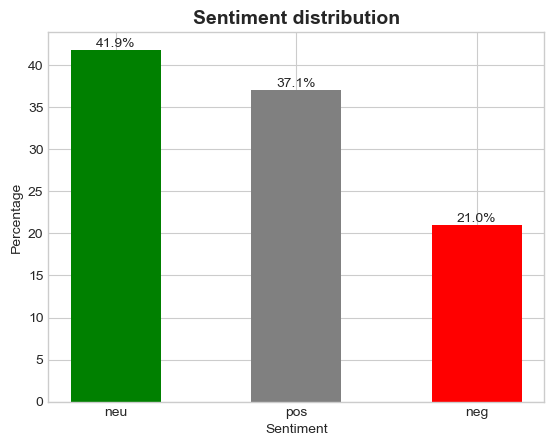

In [64]:
# 2008-2018
counts = data_miley_08_18["label"].value_counts(normalize=True) * 100

bars = plt.bar(counts.index, counts.values, color=["green", "gray", "red"], width = 0.5)

plt.style.use("seaborn-v0_8-whitegrid")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.1f}%",
        ha="center",
        va="bottom"
    )
plt.title("Sentiment distribution", fontsize=14, weight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Percentage")

plt.show()

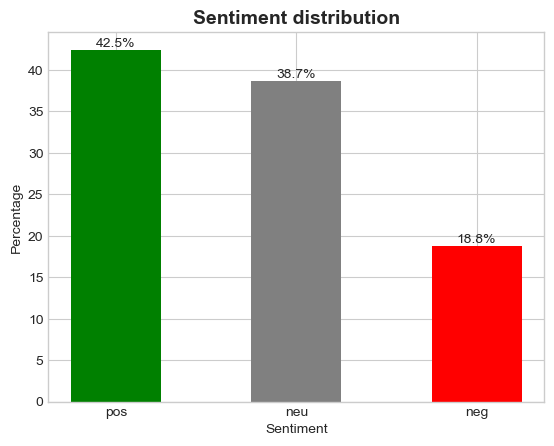

In [65]:
# 2019-2020
counts = data_miley_19_20["label"].value_counts(normalize=True) * 100

bars = plt.bar(counts.index, counts.values, color=["green", "gray", "red"], width = 0.5)

plt.style.use("seaborn-v0_8-whitegrid")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.1f}%",
        ha="center",
        va="bottom"
    )
plt.title("Sentiment distribution", fontsize=14, weight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Percentage")

plt.show()

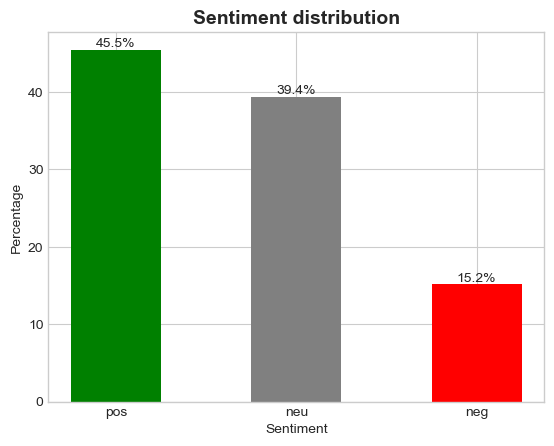

In [66]:
# 2021-2023
counts = data_miley_21_23["label"].value_counts(normalize=True) * 100

bars = plt.bar(counts.index, counts.values, color=["green", "gray", "red"], width = 0.5)

plt.style.use("seaborn-v0_8-whitegrid")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.1f}%",
        ha="center",
        va="bottom"
    )
plt.title("Sentiment distribution", fontsize=14, weight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Percentage")

plt.show()

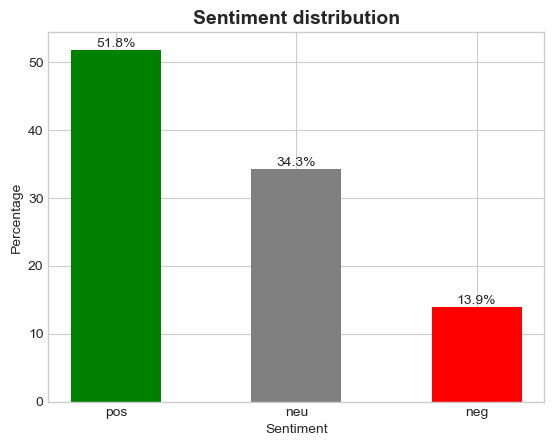

In [67]:
# 2024-2026
counts = data_miley_24_26["label"].value_counts(normalize=True) * 100

bars = plt.bar(counts.index, counts.values, color=["green", "gray", "red"], width = 0.5)

plt.style.use("seaborn-v0_8-whitegrid")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.1f}%",
        ha="center",
        va="bottom"
    )
plt.title("Sentiment distribution", fontsize=14, weight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Percentage")

plt.show()

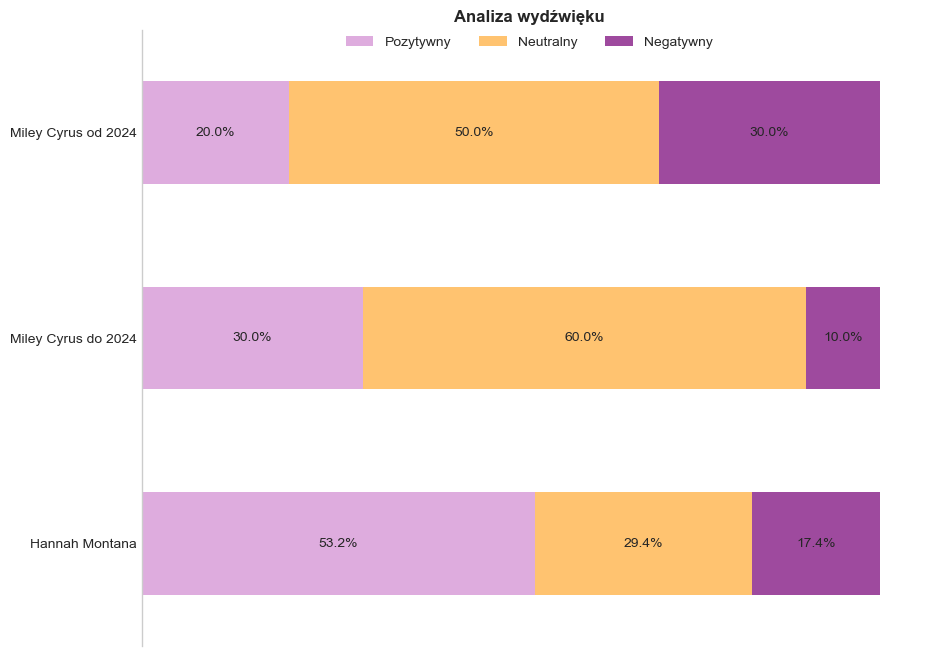

In [90]:
category_names = ["Pozytywny", "Neutralny", "Negatywny"]

colors = ["#deacde", "#ffc370","#9e4a9e"]

df = pd.DataFrame({
    "Pozytywny": [53.2, 30, 20],
    "Neutralny":[29.4, 60, 50],
    "Negatywny": [17.4, 10, 30]
}, index = ["Hannah Montana", "Miley Cyrus do 2024", "Miley Cyrus od 2024"])


ax = df.plot(kind = "barh",
             stacked = True,
             color = colors,
             figsize = (10,8))

for container in ax.containers:
    ax.bar_label(container,
                label_type = "center",
                labels = [f"{bar.get_width():.1f}%" for bar in container
    ])

ax.xaxis.set_visible(False)

ax.set_title("Analiza wydźwięku", fontweight = "bold")
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=len(df.columns),
    frameon=False
)


plt.show()